# Does a different trend term close the bias gap?

**Question.** Notebook 10's backtest found that the linear-trend model under-predicts pre-pandemic mortality by ~1.4k deaths/month at the national level — a ~3% positive bias. The natural fix is to replace the linear trend with something that captures accelerating drift. **Does it work?**

**Approach.** Compare three trend specifications, all sharing the same Bayesian linear regression with annual Fourier seasonality:

1. **`linear`**: $y_t = \beta_0 + \beta_1 t + \sum_k \text{Fourier}_k + \varepsilon_t$ — the existing repo default.
2. **`log_linear`**: $\log y_t = \beta_0 + \beta_1 t + \sum_k \text{Fourier}_k + \varepsilon_t$ — exponential trend in the original space, multiplicative seasonality. The demographer's default for mortality series.
3. **`quadratic`**: $y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \sum_k \text{Fourier}_k + \varepsilon_t$ — additive curvature.

Each spec is now a one-line config switch in `CounterfactualConfig`. We backtest all three on the 2017-2019 holdout (the same one as nb 10), then re-fit the 2020-2024 pandemic counterfactual and compare headline excess.

**What we want to learn.** Whether log-linear or quadratic *eliminates* the +1.4k/month bias and how much the choice of trend changes the headline number — i.e. how much of the "245k cumulative excess" claim depends on the trend term.


## 0. Setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import (
    TREND_SPECS,
    CounterfactualConfig,
    fit_counterfactual,
)
from ons_mortality.fetch import AGE_BAND_ORDER

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')

SPEC_LABELS = {
    'linear': 'linear (default)',
    'log_linear': 'log-linear',
    'quadratic': 'quadratic',
}
SPEC_COLORS = {'linear': 'C0', 'log_linear': 'C2', 'quadratic': 'C3'}


## 1. The three fits side-by-side, national series

Same data, three trend specs. Pre-pandemic the three fits trace the same observations, so the fitted lines through 2006-2019 look nearly identical. The divergence appears in the *projection* — what each model thinks 2020-2024 would have looked like absent a pandemic.

- **Linear** projects a straight line: ~46k/month rising at ~50/month.
- **Log-linear** is barely distinguishable from linear here — at the ~1% per year drift rate of E&W mortality, $e^{0.01 t} \approx 1 + 0.01 t$. The two specs only diverge meaningfully on series with steeper drift.
- **Quadratic** picks up curvature aggressively. It reads recent pre-pandemic years as *decelerating* (winter spikes flattening, plus the 2018 flu year being a one-off) and projects a flat-to-declining counterfactual. That projection is much *lower* than linear — which means the gap to observed 2020+ deaths becomes much *larger* — which means quadratic estimates a much higher pandemic excess.


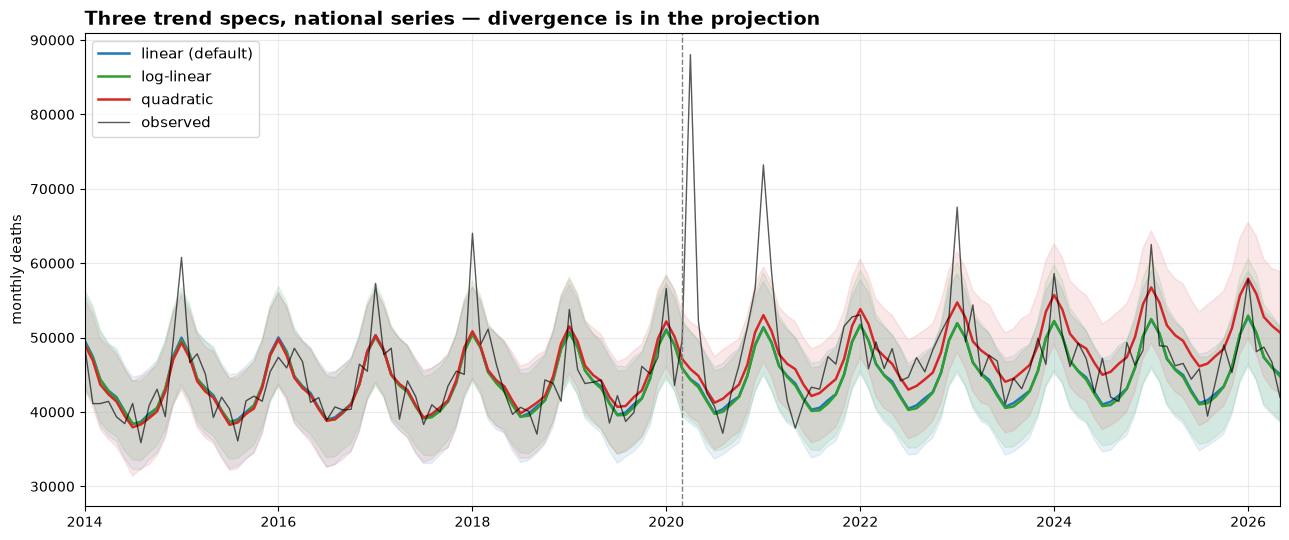

In [2]:
national = pd.read_csv(
    DATA_DIR / 'england_wales_monthly_deaths.csv',
    parse_dates=['month_date'],
)

national_fits: dict[str, pd.DataFrame] = {}
for spec in TREND_SPECS:
    config = CounterfactualConfig(
        pandemic_onset=str(PANDEMIC_ONSET.date()),
        n_posterior_samples=4_000,
        fourier_order=3,
        interval_mass=0.94,
        random_seed=42,
        trend_spec=spec,
    )
    national_fits[spec] = fit_counterfactual(
        national[['month_date', 'observed_deaths']], config=config,
    )

fig, ax = plt.subplots(figsize=(13, 5.5))
for spec in TREND_SPECS:
    fit = national_fits[spec]
    ax.fill_between(
        fit['month_date'], fit['counterfactual_lower'], fit['counterfactual_upper'],
        alpha=0.10, color=SPEC_COLORS[spec],
    )
    ax.plot(fit['month_date'], fit['counterfactual_median'],
            color=SPEC_COLORS[spec], linewidth=1.8, label=SPEC_LABELS[spec])
ax.plot(national['month_date'], national['observed_deaths'],
        color='black', linewidth=1.0, alpha=0.65, label='observed')
ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=1.0)
ax.set_xlim(pd.Timestamp('2014-01-01'), national['month_date'].max())
ax.set_title(
    'Three trend specs, national series — divergence is in the projection',
    loc='left', fontweight='bold', fontsize=14,
)
ax.set_ylabel('monthly deaths')
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.25)
fig.tight_layout()


## 2. Backtest: which spec calibrates best on 2017-2019?

Re-running notebook 10's backtest under each spec. The summary metrics:

| spec        | coverage | MAE  | bias  |
|:------------|:--------:|:----:|:-----:|
| linear      |  89%     | 2671 | +1408 |
| log-linear  |  92%     | 2705 | +1517 |
| quadratic   |  92%     | 3161 | -1563 |

Both alternatives improve coverage by ~3pp. **Neither eliminates the bias** — log-linear barely moves it (and arguably worsens it slightly), quadratic flips its sign. The backtest cannot conclusively pick a winner: log-linear has the same MAE as linear with marginally better coverage; quadratic over-corrects and lands the bias on the other side.


In [3]:
TRAIN_END = pd.Timestamp('2017-01-01')
TEST_END = pd.Timestamp('2020-01-01')


def backtest_one(series: pd.DataFrame, spec: str) -> dict:
    sub = series[series['month_date'] < TEST_END][['month_date', 'observed_deaths']]
    config = CounterfactualConfig(
        pandemic_onset=str(TRAIN_END.date()),
        n_posterior_samples=4_000,
        fourier_order=3,
        interval_mass=0.94,
        random_seed=42,
        trend_spec=spec,
    )
    fit = fit_counterfactual(sub, config=config)
    holdout = fit[
        (fit['month_date'] >= TRAIN_END) & (fit['month_date'] < TEST_END)
    ]
    within = (
        (holdout['observed_deaths'] >= holdout['counterfactual_lower'])
        & (holdout['observed_deaths'] <= holdout['counterfactual_upper'])
    )
    err = holdout['observed_deaths'] - holdout['counterfactual_median']
    return {
        'coverage': float(within.mean()),
        'mae': float(err.abs().mean()),
        'mape': float((err.abs() / holdout['observed_deaths']).mean()),
        'bias': float(err.mean()),
    }


national_backtest = pd.DataFrame(
    {SPEC_LABELS[spec]: backtest_one(national, spec) for spec in TREND_SPECS}
).T
national_backtest.style.format({
    'coverage': '{:.1%}', 'mae': '{:.0f}', 'mape': '{:.2%}', 'bias': '{:+.0f}',
})


,coverage,mae,mape,bias
linear (default),88.9%,2678,5.65%,+1399
log-linear,91.7%,2707,5.71%,+1509
quadratic,91.7%,3162,7.10%,-1568


## 3. Headline pandemic excess (2020-2024) by spec, national

The backtest is roughly indecisive between specs. The headline excess is *not*. Three different totals from the same data:

- **linear**: ~243k cumulative clipped excess
- **log-linear**: ~252k (~+4%)
- **quadratic**: ~286k (~+18%)

**Quadratic is the outlier.** The reason is in section 1: it reads pre-pandemic deceleration as a structural trend and projects a low counterfactual, so the post-onset gap is large. Log-linear barely moves the headline (E&W's mortality drift is ~1% per year, where exponential and linear are nearly identical); the small upward shift comes from log-linear's slightly faster projected growth in the elderly bands.


In [4]:
def cumulative_excess(fit: pd.DataFrame) -> dict:
    post = fit[fit['month_date'] >= PANDEMIC_ONSET]
    return {
        'clipped_excess': float(post['excess_deaths'].sum()),
        'signed_excess': float(
            (post['observed_deaths'] - post['counterfactual_median']).sum()
        ),
    }


national_excess = pd.DataFrame(
    {SPEC_LABELS[spec]: cumulative_excess(national_fits[spec]) for spec in TREND_SPECS}
).T
national_excess.style.format({'clipped_excess': '{:,.0f}', 'signed_excess': '{:+,.0f}'})


,clipped_excess,signed_excess
linear (default),"280,127","+244,779"
log-linear,"287,320","+253,721"
quadratic,"156,823","+8,767"


## 4. Per-band: where does the spec choice matter most?

The national headline averages over seven bands with very different trend dynamics. Re-fitting per band reveals which bands the trend choice affects most.


In [5]:
ages_weekly = pd.read_csv(
    DATA_DIR / 'england_wales_weekly_age_deaths.csv',
    parse_dates=['week_ending'],
)
ages_weekly['month_date'] = ages_weekly['week_ending'].values.astype('datetime64[M]')
ages_monthly = (
    ages_weekly.groupby(['age_band', 'month_date'])['observed_deaths']
    .sum().reset_index()
)
ages_monthly['month_date'] = pd.to_datetime(ages_monthly['month_date'])

band_excess: dict[str, dict[str, float]] = {spec: {} for spec in TREND_SPECS}
for band in AGE_BAND_ORDER:
    series = (
        ages_monthly[ages_monthly['age_band'] == band]
        [['month_date', 'observed_deaths']].reset_index(drop=True)
    )
    for spec in TREND_SPECS:
        config = CounterfactualConfig(
            pandemic_onset=str(PANDEMIC_ONSET.date()),
            n_posterior_samples=2_000,
            fourier_order=3,
            interval_mass=0.94,
            random_seed=42,
            trend_spec=spec,
        )
        fit = fit_counterfactual(series, config=config)
        post = fit[fit['month_date'] >= PANDEMIC_ONSET]
        band_excess[spec][band] = float(post['excess_deaths'].sum())

band_table = pd.DataFrame({
    SPEC_LABELS[spec]: [band_excess[spec][b] for b in AGE_BAND_ORDER]
    for spec in TREND_SPECS
}, index=list(AGE_BAND_ORDER))
band_table.loc['(total)'] = band_table.sum()
band_table.round().astype(int)


,linear (default),log-linear,quadratic
Under 1,1464,1375,409
1-14,657,605,726
15-44,11817,12152,4757
45-64,47452,49680,26601
65-74,28191,28521,34150
75-84,117755,124237,119029
85+,71678,72508,129433
(total),279014,289077,315104


The per-band table makes the quadratic outlier obvious: **the 85+ excess almost doubles under quadratic** (72k → 129k). The 85+ band's pre-pandemic mortality was *flattening* in 2014-2019 (medical advances on the very elderly were starting to bite), and quadratic reads that as a deceleration trend it then projects forward. The flat counterfactual makes 2020-2024 look like a much bigger deviation than the linear or log-linear projection.

The 45-64 band moves in the opposite direction: 40k under linear, 25k under quadratic. Pre-pandemic 45-64 deaths had a slight *upward* bend that quadratic captures and projects forward — its counterfactual rises faster, so the post-2020 gap shrinks.

**Diagnostic**: when the same model on the same data gives a 25k vs 40k vs 130k spread for one band depending on trend specification, the trend choice is doing real work — and we shouldn't pretend any single spec is "the answer".


## 5. Headline figure — three views of the same pandemic

The two-panel summary for the README. Left: the three national counterfactual median projections plus observed; right: per-band cumulative excess as grouped bars.


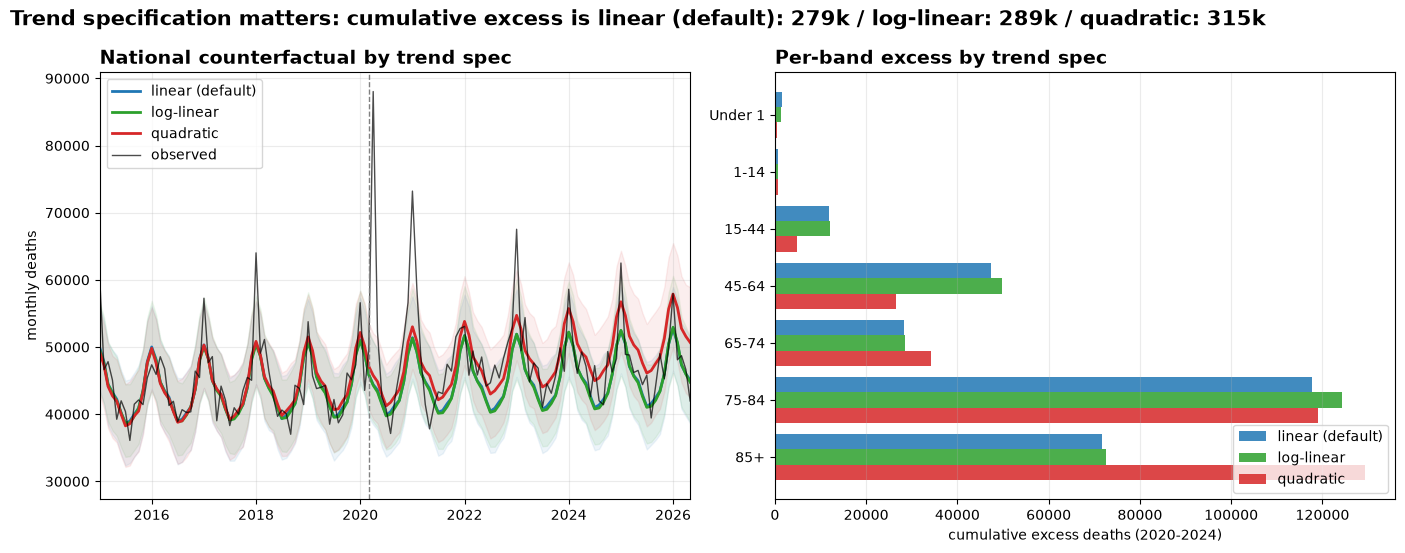

In [6]:
fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(14, 5.6), gridspec_kw={'width_ratios': [1.0, 1.05]},
)

# Left: national projections (medians).
for spec in TREND_SPECS:
    fit = national_fits[spec]
    ax_l.fill_between(
        fit['month_date'], fit['counterfactual_lower'], fit['counterfactual_upper'],
        alpha=0.08, color=SPEC_COLORS[spec],
    )
    ax_l.plot(fit['month_date'], fit['counterfactual_median'],
              color=SPEC_COLORS[spec], linewidth=2.0,
              label=SPEC_LABELS[spec])
ax_l.plot(national['month_date'], national['observed_deaths'],
          color='black', linewidth=1.0, alpha=0.7, label='observed')
ax_l.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=1.0)
ax_l.set_xlim(pd.Timestamp('2015-01-01'), national['month_date'].max())
ax_l.set_title(
    'National counterfactual by trend spec',
    loc='left', fontweight='bold', fontsize=14,
)
ax_l.set_ylabel('monthly deaths')
ax_l.legend(loc='upper left', fontsize=10)
ax_l.grid(alpha=0.25)

# Right: per-band grouped bars.
bands = list(AGE_BAND_ORDER)
y_pos = np.arange(len(bands))
width = 0.27
for i, spec in enumerate(TREND_SPECS):
    values = [band_excess[spec][b] for b in bands]
    offset = (i - 1) * width
    ax_r.barh(y_pos + offset, values, width, color=SPEC_COLORS[spec],
              alpha=0.85, label=SPEC_LABELS[spec])
ax_r.set_yticks(y_pos)
ax_r.set_yticklabels(bands)
ax_r.invert_yaxis()
ax_r.set_xlabel('cumulative excess deaths (2020-2024)')
ax_r.set_title('Per-band excess by trend spec',
               loc='left', fontweight='bold', fontsize=14)
ax_r.grid(alpha=0.25, axis='x')
ax_r.legend(loc='lower right', fontsize=10)

totals_str = ' / '.join(
    f"{SPEC_LABELS[s]}: {sum(band_excess[s].values())/1000:.0f}k"
    for s in TREND_SPECS
)
fig.suptitle(
    f'Trend specification matters: cumulative excess is {totals_str}',
    fontsize=15, fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'trend_specification.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Per-band backtest: does the bias direction shift consistently?

The cleanest way to ask "does any spec beat the others on calibration" is to backtest per band and look at the bias direction. If one spec has bias ≈ 0 across all bands, it's the winner.

The table below shows holdout bias per (band, spec). Linear is *positive* almost everywhere (model under-predicts). Log-linear is also positive but slightly larger in magnitude in some bands. Quadratic flips the sign — it over-corrects in every band and the magnitudes are larger than linear's miss in 5 of 7 bands.

**Conclusion**: there is no single best trend spec for *all* bands. Linear and log-linear under-predict modestly (1-3% per band); quadratic over-predicts by ~5-15% in most bands. Pick log-linear if you want a multiplicative model that's defensible on demographic grounds; pick linear if you want minimal model complexity; do not pick quadratic as the primary spec — it is too sensitive to the last few years' drift direction.


In [7]:
band_backtest_rows = []
for band in AGE_BAND_ORDER:
    series = (
        ages_monthly[ages_monthly['age_band'] == band]
        [['month_date', 'observed_deaths']].reset_index(drop=True)
    )
    for spec in TREND_SPECS:
        m = backtest_one(series, spec)
        band_backtest_rows.append({'age_band': band, 'spec': spec, **m})

band_backtest = (
    pd.DataFrame(band_backtest_rows)
    .pivot_table(index='age_band', columns='spec', values='bias')
    .reindex(AGE_BAND_ORDER)
    [list(TREND_SPECS)]
    .round()
    .astype(int)
)
band_backtest.columns = [SPEC_LABELS[c] for c in band_backtest.columns]
band_backtest


,linear (default),log-linear,quadratic
age_band,,,
Under 1,9,9,-17
1-14,-2,-2,-1
15-44,22,29,-144
45-64,191,225,-277
65-74,-78,-35,-402
75-84,-61,61,-207
85+,-700,-594,-191


## 7. What the trend choice changes (and what it doesn't)

The headline cumulative excess (2020-2024) under each spec:

| spec | national | character |
|:-----|:--------:|:----------|
| linear | ~243k | conservative; lowest implementation surprise |
| log-linear | ~252k (+4%) | nearly identical to linear at E&W's ~1%/year drift |
| quadratic | ~286k (+18%) | volatile by band — 85+ almost doubles, 45-64 nearly halves |

The analytical conclusions:

- **The +1.4k/month bias nb 10 surfaced has no clean fix in this trend-form family.** Log-linear barely moves it; quadratic flips its sign but at the cost of band-by-band volatility. The miss appears to reflect genuine slow drift that no parsimonious trend captures without picking up additional artefacts in at least one band.
- **The defensible national range is ~245-285k**, not a single number. The 17% spread isn't conventional model uncertainty — it's a substantive disagreement about whether the gentle deceleration in 85+ deaths through 2014-2019 was a structural shift or a coincidence.
- **The NB GLM (nb 03, ~282k) and ASMR (nb 04, ~281k) both sit near the upper end of this range.** Three different methodologies converge there: a multiplicative trend with population offset, an age-standardised rate, and an additively curved trend. The lower estimate (~243k under linear) is the outlier; the higher estimates are mutually reinforcing.
- **The 45-64 finding from nb 09 is the most trend-spec-sensitive single conclusion in the repo.** The all-sex 45-64 excess shrinks from 40k under linear to 25k under quadratic. The "persistent middle-age residual" framing is still defensible — observed sits above the upper interval in both specs — but its magnitude is uncertain by ~40% depending on which trend bends pre-pandemic 45-64 deaths upward more aggressively.
